In [53]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
data = pd.read_csv('train.csv')

In [55]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
data.shape

(891, 12)

In [57]:
(data.isna().sum() / data.shape[0]) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [58]:
# calculate null ages for each category (Mrs., Mr., NaN)

data['Title'] = data['Name'].str.extract(r'\b(Mr\.|Mrs\.)\b', expand=False, flags=re.IGNORECASE)
data['Age'] = data['Age'].fillna(data.groupby('Title')['Age'].transform('mean'))
data['Age'] = data['Age'].fillna(data['Age'].mean()).astype(int)

# fill the embarked 2 null rows with mod

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [59]:
# drop unwanted and unusable columns

data.drop(['Title','Cabin'], axis=1, inplace=True)

In [60]:
# change 'Pclass' col type to str for better visualization

data['Pclass'] = data['Pclass'].astype('str')

In [61]:
data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Visualization

In [62]:
survived_by_sex = data.groupby('Sex')['Survived'].sum()
survived_by_sex

Sex
female    233
male      109
Name: Survived, dtype: int64

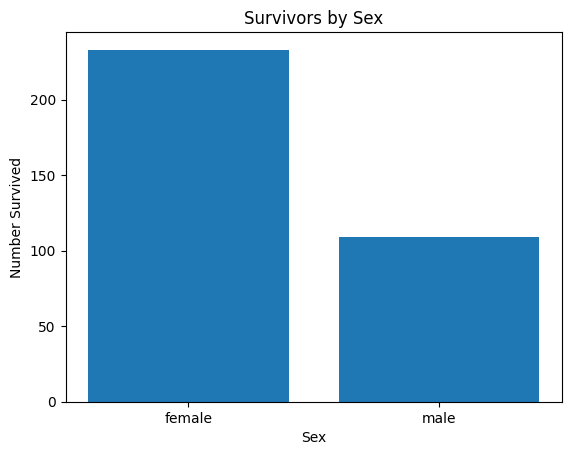

In [63]:
plt.bar(survived_by_sex.index, survived_by_sex.values)
plt.xlabel('Sex')
plt.ylabel('Number Survived')
plt.title('Survivors by Sex')
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

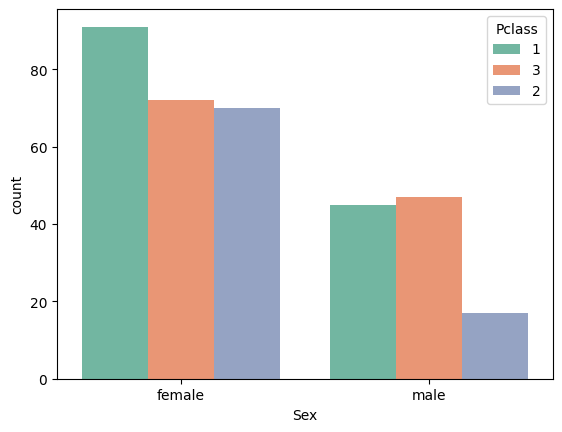

In [68]:
sns.countplot(x=data[data['Survived'] == 1]['Sex'],
               hue=data[data['Survived'] == 1]['Pclass'], palette='Set2')

<Axes: xlabel='Age', ylabel='Count'>

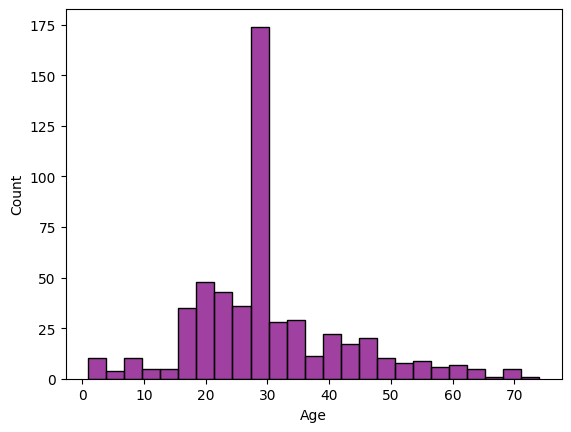

In [69]:
# unsurveyed Ages

sns.histplot(data=data[data['Survived'] == 0]['Age'],color='purple')

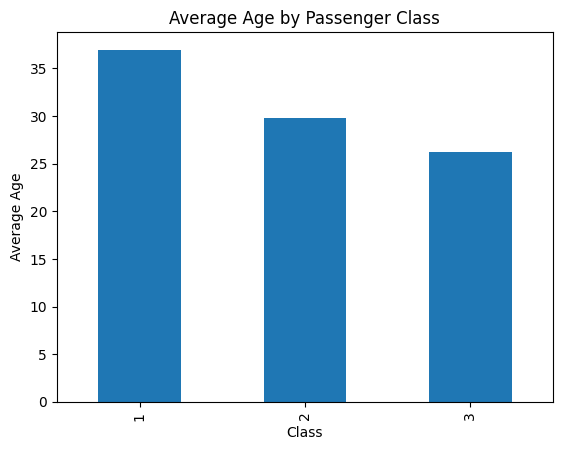

In [79]:
# avg ages for each class

data.groupby('Pclass')['Age'].mean().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Average Age')
plt.title('Average Age by Passenger Class')
plt.show()